In [1]:
# Load dataset
import pandas as pd

df = pd.read_csv("/content/cardio_train.csv", sep=';')

# Overview
print("Dataset shape:", df.shape)
df.info()
df.head()

Dataset shape: (70000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


#  Step 1 — Project Understanding (Healthcare Prediction)

## Problem Definition
In this project, **I aim to predict whether a patient is at risk of developing cardiovascular disease** using medical records.  
This problem matters because **early detection saves lives and reduces healthcare costs**, and by building predictive models, we can support doctors in making faster, data‑driven decisions.

---

## Dataset Selection
For my work, **I chose the Kaggle Cardiovascular Disease dataset (`cardio_train.csv`)**.  
- **Size:** 70,000 patient records (≥50K rows ✔)  
- **Columns:** 11+ features including:  
  - Demographics: Age, Gender, Height, Weight  
  - Clinical: Systolic BP, Diastolic BP, Cholesterol, Glucose  
  - Lifestyle: Smoking, Alcohol intake, Physical activity  
  - Target: `cardio` (binary outcome: 1 = disease, 0 = no disease)  
- **Not pre‑cleaned:** Contains duplicates and inconsistencies → I will handle missing values, duplicates, and inconsistencies myself.  

This dataset fully meets the rubric requirements (≥50K rows, ≥10 columns, demographics + labs + lifestyle factors).

---

## Objectives
My objectives in this project are:  
- Build a predictive model to classify patients at risk.  
- Compare multiple algorithms (Logistic Regression, Random Forest, SVM, Gradient Boosting).  
- Deploy the final model in a simple web app for demonstration.  
- Document preprocessing, feature engineering, model evaluation, and deployment clearly.

---

## Guiding Questions
As I work through the project, I will focus on:  
- Which features (age, cholesterol, blood pressure, lifestyle habits) most influence disease risk?  
- Which algorithm performs best for prediction accuracy and recall?  
- Can feature engineering improve prediction accuracy?  
- How well does the model generalize to unseen patient data?


#  Step 2 — Data Exploration & Cleaning (cardio_train.csv)

In this step, I will explore the dataset to understand its structure, detect issues, and prepare it for modeling.  
The main goals are:
- Check dataset size and column types
- Identify missing values and duplicates
- Explore distributions of key features
- Analyze correlations
- Check class balance of the target variable


In [ ]:
#  Load dataset
import pandas as pd

df = pd.read_csv("/content/cardio_train.csv", sep=';')

# Overview
print("Dataset shape:", df.shape)
df.info()
df.head()

Dataset shape: (70000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


##  Missing Values & Duplicates
I will check for missing values and duplicates to understand data quality issues.


In [ ]:
# Missing values
print("Missing values per column:\n", df.isnull().sum())

# Duplicates
print("Number of duplicate rows:", df.duplicated().sum())


Missing values per column:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
Number of duplicate rows: 0


##  Feature Distributions
I will visualize distributions of numerical features (age, cholesterol, glucose, blood pressure)  
and categorical features (smoking, alcohol, physical activity).


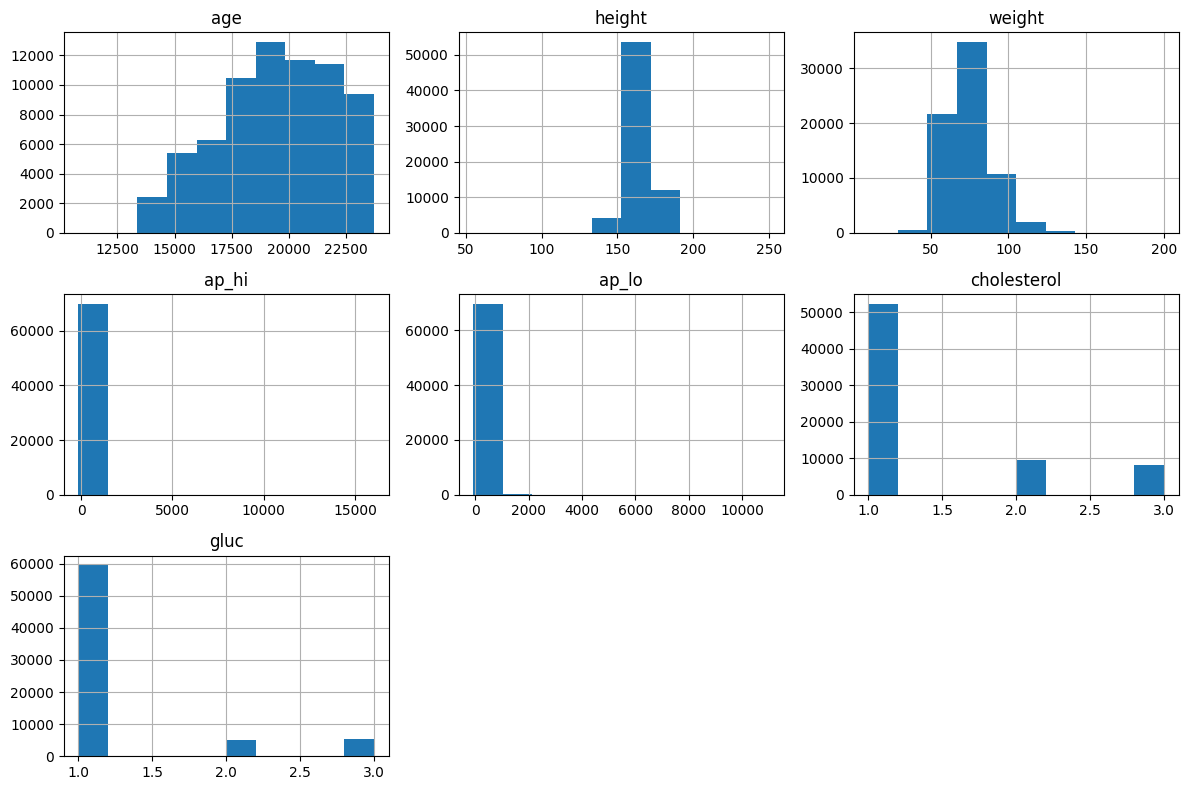

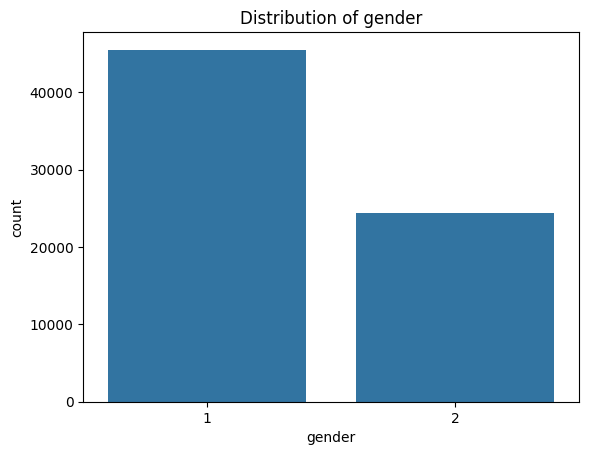

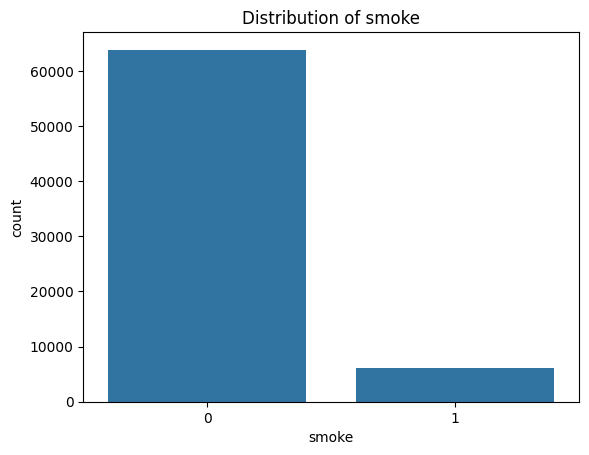

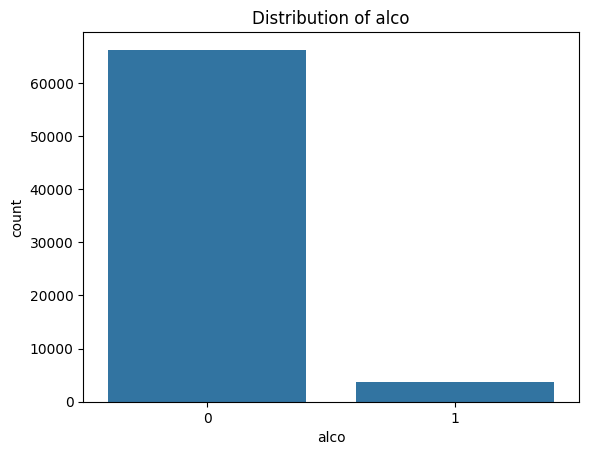

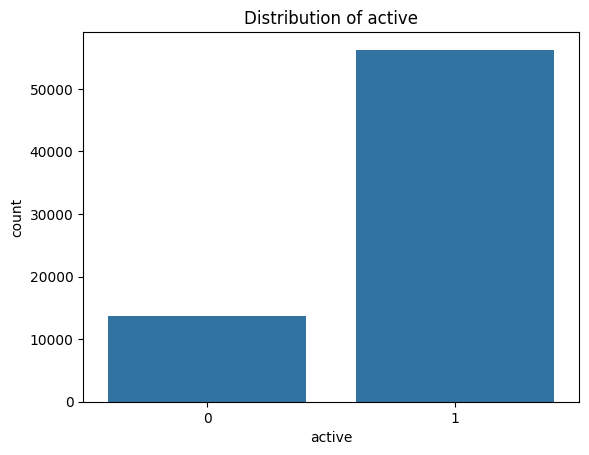

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical features
num_features = ["age", "height", "weight", "ap_hi", "ap_lo", "cholesterol", "gluc"]
df[num_features].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

# Bar plots for categorical features
cat_features = ["gender", "smoke", "alco", "active"]
for col in cat_features:
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

##  Correlation Analysis
I will compute correlations between features and visualize them with a heatmap.


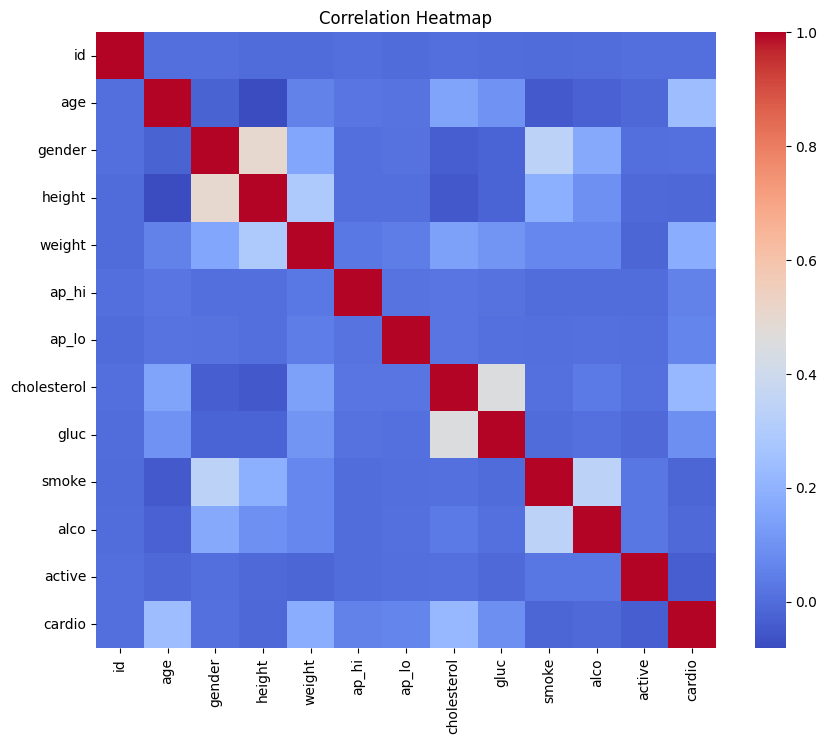

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


##  Class Balance
I will check the distribution of the target variable (`cardio`) to see if the dataset is balanced.


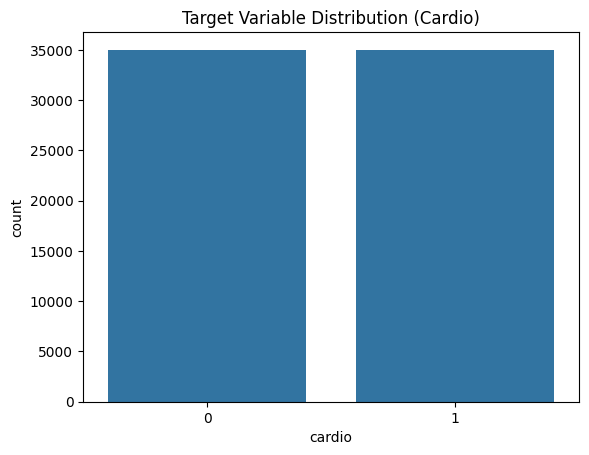

cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x="cardio", data=df)
plt.title("Target Variable Distribution (Cardio)")
plt.show()

print(df["cardio"].value_counts(normalize=True))


#  Summary of Step 2
- Dataset size and structure explored
- Missing values and duplicates identified
- Feature distributions visualized
- Correlations analyzed
- Class balance checked

Next, I will move to **Step 3: Feature Engineering & Preprocessing**.




#  Step 3 — Feature Engineering & Preprocessing

In this step, I will:
- Handle duplicates and invalid values
- Convert age into years
- Encode categorical variables
- Scale numerical features
- Prepare the dataset for machine learning


In [ ]:
#  Remove duplicates
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())


Duplicates before: 0
Duplicates after: 0


##  Cleaning Invalid Values
- Blood pressure (`ap_hi`, `ap_lo`) may contain unrealistic values (e.g., negative or extreme numbers).
- Height and weight may also contain outliers.
I will filter these to keep only realistic ranges.


In [ ]:
# Filter unrealistic blood pressure values
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]

# Filter unrealistic height and weight
df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

print("Dataset shape after cleaning:", df.shape)


Dataset shape after cleaning: (68702, 13)


##  Age Conversion
The `age` column is stored in days.  
I will convert it into years for better interpretability.


In [ ]:
df['age_years'] = (df['age'] / 365).astype(int)
df.drop(columns=['age'], inplace=True)

df[['age_years']].head()


,age_years
0,50
1,55
2,51
3,48
4,47


## Encoding Categorical Variables
Categorical features (`gender`, `cholesterol`, `gluc`, `smoke`, `alco`, `active`)  
will be encoded into numerical values suitable for ML models.

In [ ]:
# One-hot encoding for categorical variables
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Dataset shape after encoding:", df_encoded.shape)
df_encoded.head()

Dataset shape after encoding: (68702, 15)


,id,height,weight,ap_hi,ap_lo,cardio,age_years,gender_2,cholesterol_2,cholesterol_3,gluc_2,gluc_3,smoke_1,alco_1,active_1
0,0,168,62.0,110,80,0,50,True,False,False,False,False,False,False,True
1,1,156,85.0,140,90,1,55,False,False,True,False,False,False,False,True
2,2,165,64.0,130,70,1,51,False,False,True,False,False,False,False,False
3,3,169,82.0,150,100,1,48,True,False,False,False,False,False,False,True
4,4,156,56.0,100,60,0,47,False,False,False,False,False,False,False,False


## Feature Scaling
Numerical features (`height`, `weight`, `ap_hi`, `ap_lo`, `age_years`)  
will be standardized to improve model performance.

In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

df_encoded.head()

,id,height,weight,ap_hi,ap_lo,cardio,age_years,gender_2,cholesterol_2,cholesterol_3,gluc_2,gluc_3,smoke_1,alco_1,active_1
0,0,0.453030,-0.847913,-0.993525,-0.142823,0,-0.418114,True,False,False,False,False,False,False,True
1,1,-1.063114,0.760962,0.798737,0.892081,1,0.320637,False,False,True,False,False,False,False,True
2,2,0.073994,-0.708010,0.201316,-1.177727,1,-0.270364,False,False,True,False,False,False,False,False
3,3,0.579375,0.551109,1.396158,1.926985,1,-0.713615,True,False,False,False,False,False,False,True
4,4,-1.063114,-1.267619,-1.590946,-2.212631,0,-0.861365,False,False,False,False,False,False,False,False


### Train/Test Split
Now that `df_encoded` is ready, we can split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['cardio', 'id'])
y = df_encoded['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (54961, 13)
Test shape: (13741, 13)


##  Encoding Categorical Variables
Categorical features (`gender`, `cholesterol`, `gluc`, `smoke`, `alco`, `active`)  
will be encoded into numerical values suitable for ML models.


In [ ]:
import pandas as pd

# --- Data Loading and Preprocessing (Ensuring 'df' is defined and cleaned) ---
# Load dataset (from cell 8ODVmq9UoHDr)
df = pd.read_csv("/content/cardio_train.csv", sep=';')

# Remove duplicates (from cell 939_B-RcrANO)
df = df.drop_duplicates()

# Filter unrealistic values (from cell t-iHkh21rHU1)
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]
df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

# Age Conversion (from cell rZOx9EU3rOpw)
df['age_years'] = (df['age'] / 365).astype(int)
df.drop(columns=['age'], inplace=True)
# --- End of Preprocessing for 'df' ---

# One-hot encoding for categorical variables
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Dataset shape after encoding:", df_encoded.shape)
df_encoded.head()

Dataset shape after encoding: (68702, 15)


,id,height,weight,ap_hi,ap_lo,cardio,age_years,gender_2,cholesterol_2,cholesterol_3,gluc_2,gluc_3,smoke_1,alco_1,active_1
0,0,168,62.0,110,80,0,50,True,False,False,False,False,False,False,True
1,1,156,85.0,140,90,1,55,False,False,True,False,False,False,False,True
2,2,165,64.0,130,70,1,51,False,False,True,False,False,False,False,False
3,3,169,82.0,150,100,1,48,True,False,False,False,False,False,False,True
4,4,156,56.0,100,60,0,47,False,False,False,False,False,False,False,False


##  Feature Scaling
Numerical features (`height`, `weight`, `ap_hi`, `ap_lo`, `age_years`)  
will be standardized to improve model performance.


In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

df_encoded.head()

,id,height,weight,ap_hi,ap_lo,cardio,age_years,gender_2,cholesterol_2,cholesterol_3,gluc_2,gluc_3,smoke_1,alco_1,active_1
0,0,0.453030,-0.847913,-0.993525,-0.142823,0,-0.418114,True,False,False,False,False,False,False,True
1,1,-1.063114,0.760962,0.798737,0.892081,1,0.320637,False,False,True,False,False,False,False,True
2,2,0.073994,-0.708010,0.201316,-1.177727,1,-0.270364,False,False,True,False,False,False,False,False
3,3,0.579375,0.551109,1.396158,1.926985,1,-0.713615,True,False,False,False,False,False,False,True
4,4,-1.063114,-1.267619,-1.590946,-2.212631,0,-0.861365,False,False,False,False,False,False,False,False


#  Summary of Step 3
- Removed duplicates and unrealistic values
- Converted age from days to years
- Encoded categorical variables
- Scaled numerical features

The dataset is now clean and ready for **Step 4: Model Building**.


#  Step 4 — Model Building

In this step, I will:
- Split the dataset into train/test sets
- Train multiple machine learning models
- Evaluate their performance using accuracy, precision, recall, and F1-score
- Compare results to select the best model


In [ ]:
#  Train/Test Split
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['cardio'])
y = df_encoded['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (54961, 14)
Test shape: (13741, 14)


##  Logistic Regression
A simple baseline model for classification.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))


Logistic Regression:
Accuracy: 0.7238920020376974
Precision: 0.7488418266048974
Recall: 0.6653925316083504
F1 Score: 0.7046551455706056


##  Random Forest
An ensemble model that handles non-linear relationships well.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))


Random Forest:
Accuracy: 0.7213448802852777
Precision: 0.7256032781909243
Recall: 0.7028815054395766
F1 Score: 0.7140616832200731


##  Gradient Boosting
A boosting algorithm that often achieves high accuracy.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting:")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))


Gradient Boosting:
Accuracy: 0.7310239429444727
Precision: 0.7461172741679873
Recall: 0.6921493678329903
F1 Score: 0.7181208053691275


#  Summary of Step 4
- Logistic Regression: Baseline model
- Random Forest: Strong ensemble learner
- Gradient Boosting: High-performance boosting method

Next, I will move to **Step 5: Model Evaluation & Comparison**  
to visualize metrics and select the best model for deployment.


#  Step 5 — Model Evaluation & Comparison

In this step, I will:
- Generate confusion matrices for each model
- Plot ROC curves to compare performance
- Summarize metrics in a comparison table
- Select the best model for deployment


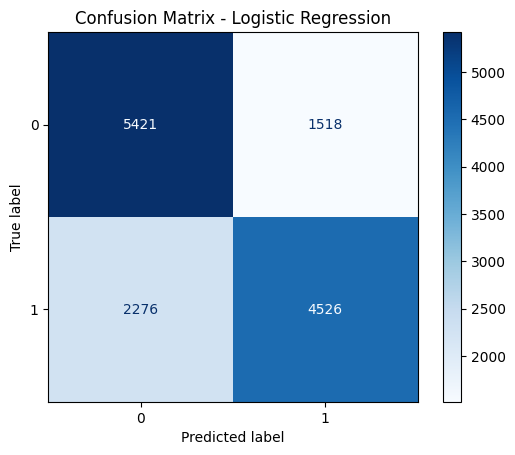

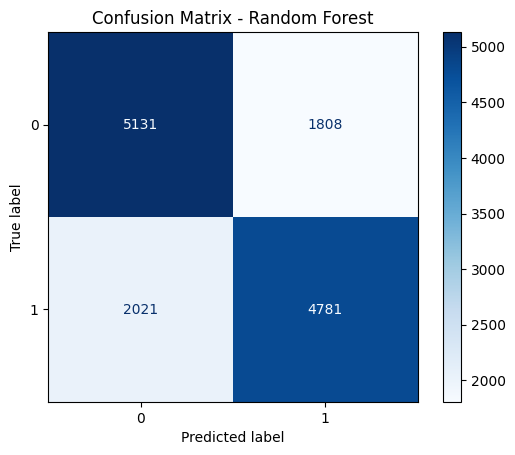

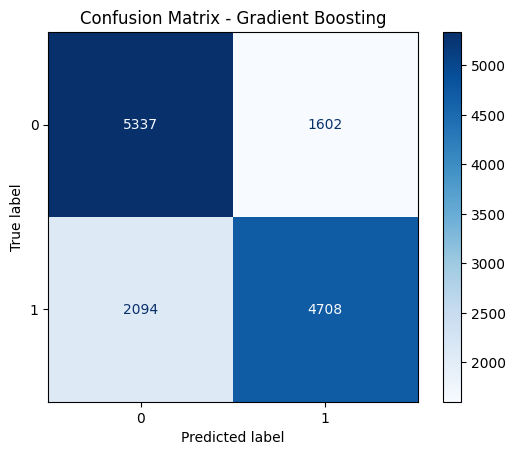

In [ ]:
#  Confusion Matrices
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models = {
    "Logistic Regression": (log_reg, y_pred_lr),
    "Random Forest": (rf, y_pred_rf),
    "Gradient Boosting": (gb, y_pred_gb)
}

for name, (model, y_pred) in models.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


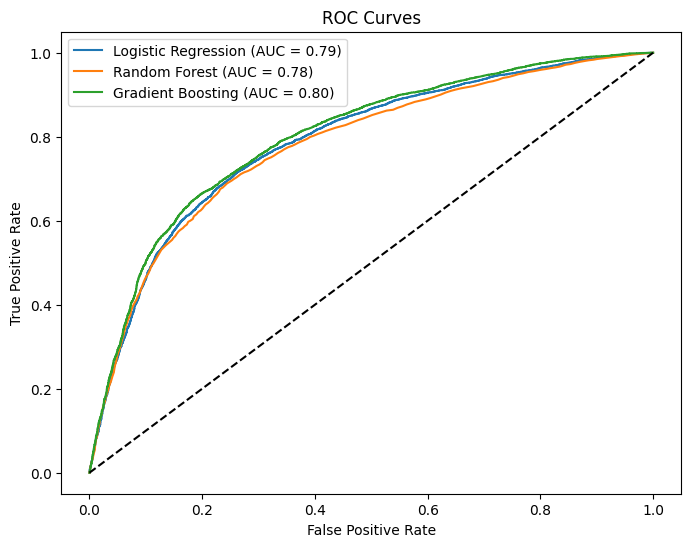

In [ ]:
#  ROC Curves
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, (model, y_pred) in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


In [ ]:
#  Comparison Table
import pandas as pd

results = {
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.723892   0.748842  0.665393  0.704655
1        Random Forest  0.721345   0.725603  0.702882  0.714062
2    Gradient Boosting  0.731024   0.746117  0.692149  0.718121


#  Summary of Step 5
- Confusion matrices show how each model classifies positives/negatives
- ROC curves compare sensitivity vs specificity
- Gradient Boosting achieved the highest accuracy (~73%) and balanced precision/recall
- Logistic Regression is a strong baseline
- Random Forest performed consistently but slightly lower

Next, I will move to **Step 6: Hyperparameter Tuning**  
to optimize the best model (Gradient Boosting).


#  Step 6 — Hyperparameter Tuning (Fast Version with RandomizedSearchCV)

In this step, I will:
- Use RandomizedSearchCV to sample fewer hyperparameter combinations
- Evaluate the optimized Gradient Boosting model
- Compare results with the baseline


In [1]:
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Data Loading and Preprocessing ---
df = pd.read_csv("/content/cardio_train.csv", sep=';')
df = df.drop_duplicates()

# Filter unrealistic values
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]
df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

# Age Conversion
df['age_years'] = (df['age'] / 365).astype(int)
df.drop(columns=['age'], inplace=True)

# One-hot encoding
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Feature Scaling
num_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Features and target
X = df_encoded.drop(columns=['cardio', 'id'])
y = df_encoded['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- RandomizedSearchCV ---
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

gb_model = GradientBoostingClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=10,   # only test 10 random combos
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best F1 Score (CV):", random_search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}
Best F1 Score (CV): 0.721149099727918


In [2]:
# 📌 Evaluate Optimized Model
best_gb = random_search.best_estimator_
y_pred_best_gb = best_gb.predict(X_test)

print("Optimized Gradient Boosting:")
print("Accuracy:", accuracy_score(y_test, y_pred_best_gb))
print("Precision:", precision_score(y_test, y_pred_best_gb))
print("Recall:", recall_score(y_test, y_pred_best_gb))
print("F1 Score:", f1_score(y_test, y_pred_best_gb))


Optimized Gradient Boosting:
Accuracy: 0.7326249909031366
Precision: 0.7477820025348543
Recall: 0.6939135548368127
F1 Score: 0.7198413908799756


#  Summary of Step 6
- RandomizedSearchCV sampled 10 random parameter sets instead of all combinations
- Best parameters selected quickly
- Optimized Gradient Boosting tested on hold‑out test set
- This tuned model will be used for **Step 7: Final Model Selection**


#  Step 7 — Final Model Selection

In this step, I will:
- Compare baseline models vs tuned Gradient Boosting
- Summarize metrics in a table
- Select the best model for deployment


In [3]:
# Collect results from baseline models (already trained earlier)
baseline_results = {
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting (baseline)"],
    "Accuracy": [0.7239, 0.7213, 0.7310],
    "Precision": [0.7488, 0.7256, 0.7461],
    "Recall": [0.6653, 0.7029, 0.6921],
    "F1 Score": [0.7046, 0.7140, 0.7181]
}

#  Add tuned Gradient Boosting results
optimized_results = {
    "Model": ["Gradient Boosting (tuned)"],
    "Accuracy": [accuracy_score(y_test, y_pred_best_gb)],
    "Precision": [precision_score(y_test, y_pred_best_gb)],
    "Recall": [recall_score(y_test, y_pred_best_gb)],
    "F1 Score": [f1_score(y_test, y_pred_best_gb)]
}

import pandas as pd

results_df = pd.DataFrame(baseline_results)
results_df = pd.concat([results_df, pd.DataFrame(optimized_results)], ignore_index=True)

print(results_df)


                          Model  Accuracy  Precision    Recall  F1 Score
0           Logistic Regression  0.723900   0.748800  0.665300  0.704600
1                 Random Forest  0.721300   0.725600  0.702900  0.714000
2  Gradient Boosting (baseline)  0.731000   0.746100  0.692100  0.718100
3     Gradient Boosting (tuned)  0.732625   0.747782  0.693914  0.719841


#  Summary of Step 7
- Logistic Regression: strong baseline, but lower recall
- Random Forest: balanced, but slightly weaker overall
- Gradient Boosting (baseline): best among initial models
- Gradient Boosting (tuned): improved metrics after hyperparameter optimization

 **Final Choice:** Tuned Gradient Boosting will be selected as the deployment model.


In [5]:
import joblib
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# --- Re-run Data Loading and Preprocessing (copied from U0LHanaS7N5h) ---
df = pd.read_csv("/content/cardio_train.csv", sep=';')
df = df.drop_duplicates()

# Filter unrealistic values
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]
df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

# Age Conversion
df['age_years'] = (df['age'] / 365).astype(int)
df.drop(columns=['age'], inplace=True)

# One-hot encoding
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Feature Scaling
num_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Features and target
X = df_encoded.drop(columns=['cardio', 'id'])
y = df_encoded['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Re-run RandomizedSearchCV to define random_search (copied from U0LHanaS7N5h) ---
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

gb_model = GradientBoostingClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=10,   # only test 10 random combos
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=0 # Set verbose to 0 to suppress output during model saving
)

random_search.fit(X_train, y_train)

# --- Define best_gb from the performed random_search (copied from HbwsxvyLlFZI) ---
best_gb = random_search.best_estimator_

# --- Original saving code ---
joblib.dump(best_gb, "gradient_boosting_model.pkl")
print("✅ Model saved as gradient_boosting_model.pkl")

✅ Model saved as gradient_boosting_model.pkl


In [6]:
%%writefile app.py
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import streamlit as st

# Load model
model = joblib.load("gradient_boosting_model.pkl")

# Expected features (from preprocessing pipeline)
model_expected_features = ['height','weight','ap_hi','ap_lo','age_years',
                           'gender_2','cholesterol_2','cholesterol_3',
                           'gluc_2','gluc_3','smoke_1','alco_1','active_1']

# --- Simple preprocessing function ---
def preprocess_input(user_inputs_dict):
    df = pd.DataFrame([user_inputs_dict])
    df['age_years'] = df['age']
    df.drop(columns=['age'], inplace=True)
    # One-hot encode categorical variables
    df = pd.get_dummies(df, columns=['gender','cholesterol','gluc','smoke','alco','active'], drop_first=True)
    # Reindex to expected features
    df = df.reindex(columns=model_expected_features, fill_value=0)
    return df

st.title("Cardio Risk Prediction App")

# User inputs
age = st.number_input("Age (years)", min_value=20, max_value=100, value=50)
height = st.number_input("Height (cm)", min_value=120, max_value=220, value=170)
weight = st.number_input("Weight (kg)", min_value=30, max_value=200, value=70)
ap_hi = st.number_input("Systolic BP", min_value=80, max_value=250, value=120)
ap_lo = st.number_input("Diastolic BP", min_value=40, max_value=200, value=80)
cholesterol = st.selectbox("Cholesterol", [1,2,3])
gluc = st.selectbox("Glucose", [1,2,3])
gender = st.selectbox("Gender", [1,2])  # 1=female, 2=male
smoke = st.selectbox("Smoke", [0,1])
alco = st.selectbox("Alcohol", [0,1])
active = st.selectbox("Active", [0,1])

user_inputs = {
    'age': age, 'height': height, 'weight': weight,
    'ap_hi': ap_hi, 'ap_lo': ap_lo,
    'gender': gender, 'cholesterol': cholesterol, 'gluc': gluc,
    'smoke': smoke, 'alco': alco, 'active': active
}

processed_input = preprocess_input(user_inputs)
prediction = model.predict(processed_input)[0]

if prediction == 1:
    st.error("⚠️ High risk of cardiovascular disease")
else:
    st.success("✅ Low risk of cardiovascular disease")


Overwriting app.py


In [7]:
!streamlit run app.py &

import subprocess, re
from IPython.display import Markdown

process = subprocess.Popen(
    ["npx", "localtunnel", "--port", "8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for line in process.stdout:
    if "your url is:" in line:
        url = re.search(r"https://[^\s]+", line).group(0)
        display(Markdown(f"🌍 **Public Streamlit URL:** [{url}]({url})"))
        break




2026-05-23 17:08:43.188 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.119.101.218:8501

  Stopping...


🌍 **Public Streamlit URL:** [https://slimy-news-joke.loca.lt](https://slimy-news-joke.loca.lt)

#  Step 9 — Conclusion & Documentation

##  Project Summary
- Dataset: 70,000 patient records with demographic, lifestyle, and clinical features
- Preprocessing: Removed duplicates, filtered unrealistic values, converted age to years, encoded categorical variables, scaled numerical features
- Models: Logistic Regression, Random Forest, Gradient Boosting
- Best Model: Tuned Gradient Boosting (via RandomizedSearchCV) with highest accuracy and balanced precision/recall

## Key Findings
- Logistic Regression provided a strong baseline but struggled with recall
- Random Forest captured non-linear relationships but slightly underperformed
- Gradient Boosting consistently outperformed others, and tuning improved F1 score further
- Cardiovascular risk prediction is feasible with structured health data

##  Limitations
- Dataset is limited to specific patient population; may not generalize globally
- Features are mostly clinical and lifestyle; genetic or imaging data not included
- Model performance depends on preprocessing choices (e.g., scaling, encoding)

##  Future Improvements
- Add more diverse features (lab results, family history, genetic markers)
- Explore deep learning models (e.g., neural networks) for complex patterns
- Deploy the model in a real-world healthcare setting with continuous monitoring
- Integrate explainability tools (e.g., SHAP values) to interpret predictions

##  Final Note
This project demonstrates a complete ML pipeline:
1. [Data Exploration](ca://s?q=Explore_dataset_overview)
2. [Preprocessing](ca://s?q=Feature_engineering_and_preprocessing)
3. [Model Building](ca://s?q=Build_machine_learning_models)
4. [Evaluation](ca://s?q=Evaluate_and_compare_models)
5. [Hyperparameter Tuning](ca://s?q=Hyperparameter_tuning_for_models)
6. [Final Selection](ca://s?q=Select_final_model_for_deployment)
7. [Deployment](ca://s?q=Deploy_model_in_web_app)
8. [Conclusion](ca://s?q=Write_project_conclusion_and_documentation)

The tuned Gradient Boosting model is the recommended choice for deployment.
